In [1]:
import sphviewer
import bacco
import matplotlib.pyplot as plt
import h5py
import numpy as np
import matplotlib as mpl

basePath = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_13/hydro_output/"

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264

# zoom = bacco.Simulation(basedir=basePath, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap),
#                         dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
#                         tau=tau, ns=ns, sigma8=sigma8, tree_file="groups_{:03d}/subhalo_prog_{:03d}".format(snap,snap), use_ids=False, numpart=4320)

In [2]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [3]:
def get_normalized_image(image, vmin=None, vmax=None):
    if vmin is None:
        vmin = np.min(image)
    if vmax is None:
        vmax = np.max(image)

    image = np.clip(image, vmin, vmax)
    image = (image - vmin) / (vmax - vmin)

    return image

In [4]:
dm = {}
gas = {}
stars = {}
with h5py.File(basePath+"/snapdir_264/snapshot_264.0.hdf5", 'r') as file:
    dm['ids'] = np.array(file['PartType1']['ParticleIDs'], dtype=np.uint64)
    dm['pos'] = file['PartType1']['Coordinates'][...]

    gas['pos'] = file['PartType0']['Coordinates'][...]
    gas['mass'] = file['PartType0']['Masses'][...]

    stars['pos'] = file['PartType4']['Coordinates'][...]
    stars['mass'] = file['PartType4']['Masses'][...]

    print(file['PartType0'].keys())

<KeysViewHDF5 ['Acceleration', 'AllowRefinement', 'CenterOfMass', 'Coordinates', 'Density', 'ElectronAbundance', 'GFM_AGNRadiation', 'GFM_CoolingRate', 'GFM_Metallicity', 'GFM_Metals', 'GFM_WindDMVelDisp', 'GFM_WindHostHaloMass', 'HighResGasMass', 'InternalEnergy', 'Masses', 'NeutralHydrogenAbundance', 'ParticleIDs', 'Potential', 'StarFormationRate', 'Velocities']>


In [5]:
with h5py.File(basePath+"/groups_264/fof_subhalo_tab_264.0.hdf5", 'r') as file:
    lenType = file['Subhalo']['SubhaloLenType'][...]

In [6]:
dm['offsets'] = np.cumsum( np.hstack(([0], lenType[:,1])) )
gas['offsets'] = np.cumsum( np.hstack(([0], lenType[:,0])) )
stars['offsets'] = np.cumsum( np.hstack(([0], lenType[:,4])) )

In [7]:
ids = dm['ids'][dm['offsets'][0]:dm['offsets'][1]]

In [8]:
isub = 0

print(stars['offsets'][isub] - stars['offsets'][isub+1])

dm_pos = dm['pos'][dm['offsets'][isub]:dm['offsets'][isub+1],:]
dm_mass = np.ones(dm_pos.shape[0])

star_pos = stars['pos'][stars['offsets'][isub]:stars['offsets'][isub+1],:]
star_mass = stars['mass'][stars['offsets'][isub]:stars['offsets'][isub+1]]
#h_stars = 5e-3 * np.ones(len(star_mass))

gas_pos = gas['pos'][gas['offsets'][isub]:gas['offsets'][isub+1],:]
gas_mass = gas['mass'][gas['offsets'][isub]:gas['offsets'][isub+1]]

-71191


In [9]:
cmap_stars = mpl.cm.bone
cmap_gas = mpl.cm.magma
cmap_dm = mpl.cm.Greys_r

In [10]:
cm = np.array([np.mean(dm_pos[:,i]) for i in range(3)])

In [11]:
r = 20
zoom = 14

In [12]:
# gas Picture
Particles = sphviewer.Particles(gas['pos'],gas['mass'])
Scene = sphviewer.Scene(Particles)
Scene.update_camera(r=r, t=0, x=cm[0], y=cm[1], z=cm[2], zoom=zoom, xsize=2160, ysize=2160)

Render = sphviewer.Render(Scene)
Render.set_logscale()

gas_img = Render.get_image()

In [13]:
# Stars Picture
Particles = sphviewer.Particles(stars['pos'],stars['mass'])
Scene = sphviewer.Scene(Particles)
Scene.update_camera(r=r, t=0, x=cm[0], y=cm[1], z=cm[2], zoom=zoom, xsize=2160, ysize=2160)

Render = sphviewer.Render(Scene)
Render.set_logscale()

stars_img = Render.get_image()
extent = Render.get_extent()

In [14]:
# dm Picture
Particles = sphviewer.Particles(dm['pos'], np.ones(dm['pos'].shape))
Scene = sphviewer.Scene(Particles)
Scene.update_camera(r=r, t=0, x=cm[0], y=cm[1], z=cm[2], zoom=zoom, xsize=2160, ysize=2160)

Render = sphviewer.Render(Scene)
Render.set_logscale()

dm_img = Render.get_image()
extent = Render.get_extent()

In [15]:
Scene.Camera.get_params()

{'x': 89.22862,
 'y': 319.94196,
 'z': 373.06702,
 'r': 20,
 't': 0,
 'p': 0,
 'zoom': 14,
 'roll': 0,
 'xsize': 2160,
 'ysize': 2160,
 'extent': None}

[]

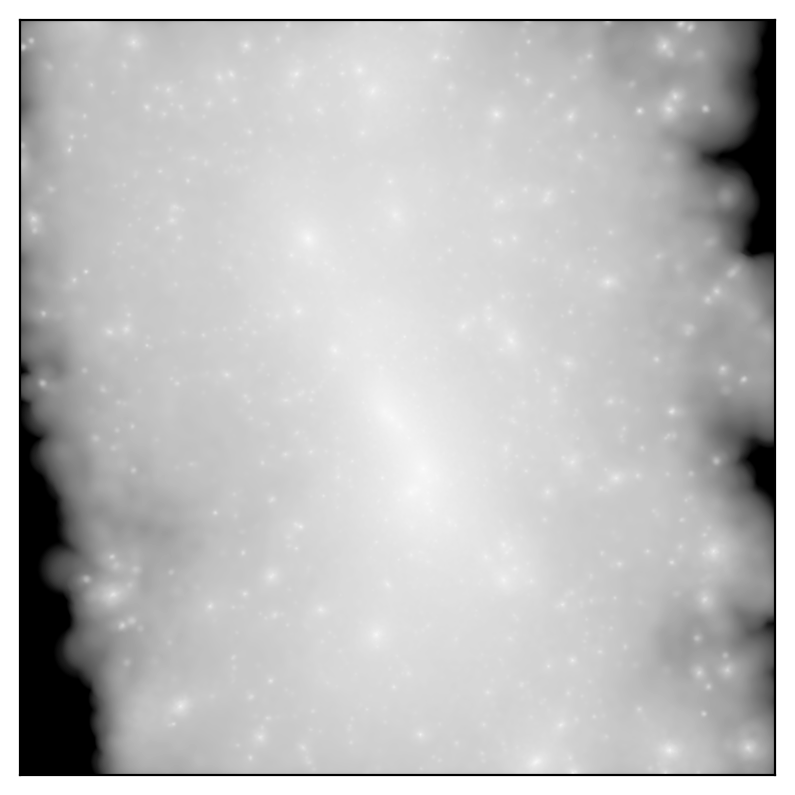

In [16]:
fig, ax = plt.subplots(dpi=200, figsize=(6, 5))

ax.imshow(dm_img, extent=extent, origin='lower', cmap='Greys_r')
ax.set_xticks([])
ax.set_yticks([])

# plt.savefig('/lscratch/fgmaion/MTNG-resims/images/dm_BCG_halo_0_LH13.pdf', bbox_inches='tight')

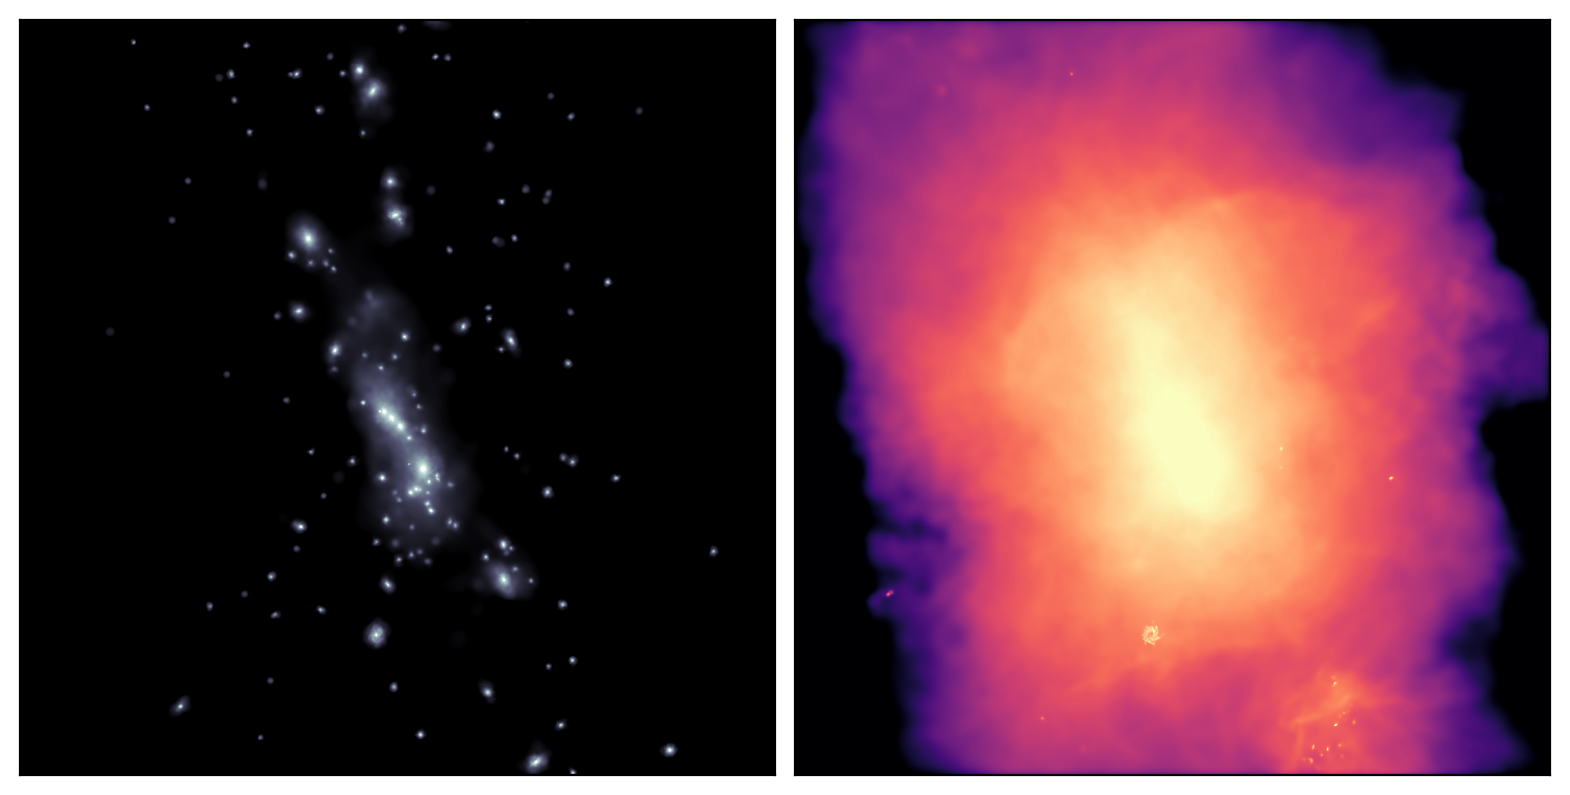

In [17]:
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(10, 5))

ax[0].imshow(stars_img, extent=extent, origin='lower', cmap='bone', vmin=0.5, vmax=3.5)
ax[1].imshow(gas_img, extent=extent, origin='lower', cmap='magma', vmin=0.7, vmax=3)

ax[0].set_xticks([])
ax[1].set_xticks([])

ax[0].set_yticks([])
ax[1].set_yticks([])

plt.subplots_adjust(wspace=0, hspace=0)

#plt.savefig('/lscratch/fgmaion/MTNG-resims/images/BCG_halo_0_LH13.pdf', bbox_inches='tight')

In [55]:
setup_image = {}

setup_image['width'] = 2.5
setup_image['x_pix'] = 1024
setup_image['y_pix'] = 1024

setup_image['dx'] = (0,0,20)
setup_image['up'] = (0,1,0)
setup_image['zclip'] = (20-10, 20+10)

In [56]:
#for the accuracy

mass = 1

center = cm
vis = bacco.Visualization(pos=dm['pos'], npix=(setup_image['x_pix'], setup_image['y_pix']), boxsize=500)
vis.set_ortho_projection(eye=center+setup_image['dx'], lookat=center, up=setup_image['up'], width=setup_image['width'], zclip=setup_image['zclip'], height=None, wrapto=None)
rho =  vis.image(maxngrid=20, nthreads=8, tetlistmode=True, norm='rhomean', mass=mass)
vmin = 0.01 * np.max(rho)
vmax = np.max(rho)
ax = bacco.visualization.show_image(rho, filename=None, vmin=vmin, vmax=vmax, colormap=mpl.cm.twilight_shifted, closefig=False, returnax=True)

In [20]:
rgb_dm = cmap_dm(get_normalized_image(dm_img, 1, 5))
rgb_gas = cmap_gas(get_normalized_image(gas_img, 0, 3))
rgb_stars = cmap_stars(get_normalized_image(stars_img, 0.5, 2.5))

In [21]:
from sphviewer.tools import Blend
blend = Blend.Blend(rgb_stars, rgb_gas)
output = blend.Screen()

In [22]:
plt.imsave('/lscratch/fgmaion/test.png', output)

#### Make movie

In [23]:
for i in range(1800):
    angle = i*360/300

    # gas Picture
    Particles = sphviewer.Particles(gas_pos,gas_mass)
    Scene = sphviewer.Scene(Particles)
    Scene.update_camera(r=3, t=angle, x=cm[0], y=cm[1], z=cm[2], zoom=14, xsize=1080, ysize=1080)

    Render = sphviewer.Render(Scene)
    Render.set_logscale()

    gas_img = Render.get_image()

    # Stars Picture
    Particles = sphviewer.Particles(star_pos,star_mass)
    Scene = sphviewer.Scene(Particles)
    Scene.update_camera(r=3, t=angle, x=cm[0], y=cm[1], z=cm[2], zoom=14, xsize=1080, ysize=1080)

    Render = sphviewer.Render(Scene)
    Render.set_logscale()

    stars_img = Render.get_image()
    extent = Render.get_extent()

    rgb_dm = cmap_dm(get_normalized_image(dm_img, 1, 5))
    rgb_gas = cmap_gas(get_normalized_image(gas_img, 0, 3))
    rgb_stars = cmap_stars(get_normalized_image(stars_img, 0.5, 2.5))

    blend = Blend.Blend(rgb_stars, rgb_gas)
    output = blend.Screen()

    plt.imsave('/cosmos_storage/home/fgmaion/movie_images/rotate{:03d}.png'.format(i), output)

KeyboardInterrupt: 

Text(0, 0.5, 'Y[Mpc/h]')

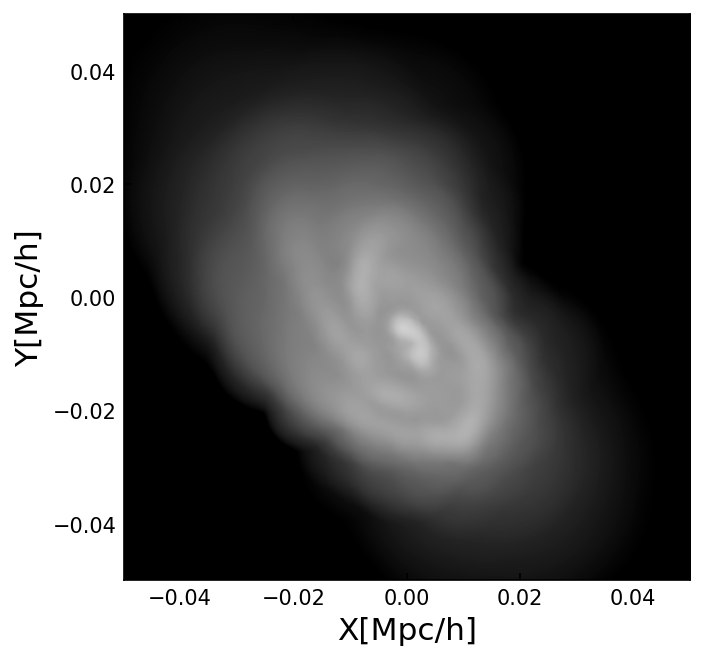

In [ ]:
fig = plt.figure(1,figsize=(5,5), dpi=150)
ax1 = fig.add_subplot(111)
ax1.imshow(gas_img, extent=extent, origin='lower', cmap='Greys_r', vmin=1, vmax=6)
ax1.set_xlabel('X[Mpc/h]', size=15)
ax1.set_ylabel('Y[Mpc/h]', size=15)

In [ ]:
from sphviewer.tools import QuickView
qv = QuickView(stars['pos'][:offsets[1],:], r=1, plot=False)
img = qv.get_image()
extent = qv.get_extent()

In [ ]:
extent

array([-45.00001,  45.00001, -45.00001,  45.00001], dtype=float32)

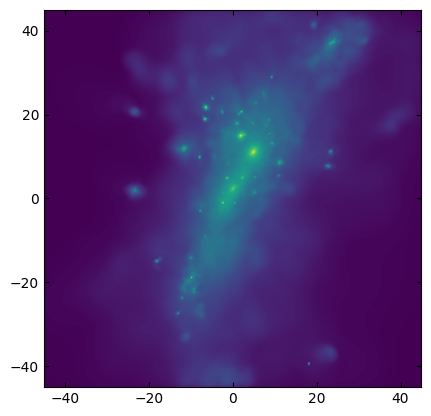

In [ ]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))

ax.imshow(img, extent=extent)

In [ ]:
from sphviewer.tools import QuickView
qv = QuickView(stars['pos'][offsets[1]:offsets[2],:], r='infinity', plot=False)
img = qv.get_image()
extent = qv.get_extent()

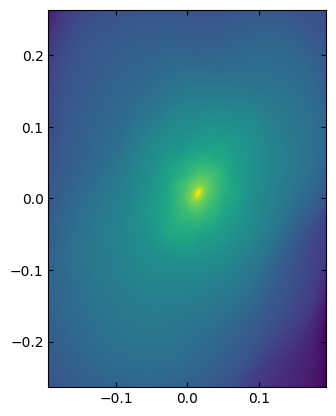

In [ ]:
fig, ax = plt.subplots(dpi=100, figsize=(5.5,5))

ax.imshow(img, extent=extent)

2024-12-17 12:21:24,078 bacco.sims : Read data for 781245/6126136 particles...
2024-12-17 12:21:24,163 bacco.sims : Read data for 781245/6126136 particles...
2024-12-17 12:21:24,166 bacco.sims : Read data for 760480/6126136 particles...
2024-12-17 12:21:24,245 bacco.sims : Read data for 760480/6126136 particles...
2024-12-17 12:21:24,249 bacco.sims : Read data for 775511/6126136 particles...


/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/snapdir_264/snapshot_264.0.hdf5


2024-12-17 12:21:24,330 bacco.sims : Read data for 775511/6126136 particles...
2024-12-17 12:21:24,334 bacco.sims : Read data for 777288/6126136 particles...
2024-12-17 12:21:24,413 bacco.sims : Read data for 777288/6126136 particles...
2024-12-17 12:21:24,416 bacco.sims : Read data for 758247/6126136 particles...
2024-12-17 12:21:24,489 bacco.sims : Read data for 758247/6126136 particles...
2024-12-17 12:21:24,492 bacco.sims : Read data for 739620/6126136 particles...
2024-12-17 12:21:24,565 bacco.sims : Read data for 739620/6126136 particles...
2024-12-17 12:21:24,568 bacco.sims : Read data for 761978/6126136 particles...
2024-12-17 12:21:24,644 bacco.sims : Read data for 761978/6126136 particles...
2024-12-17 12:21:24,648 bacco.sims : Read data for 771767/6126136 particles...
2024-12-17 12:21:24,726 bacco.sims : Read data for 771767/6126136 particles...
2024-12-17 12:21:24,790 bacco.sims :  STARS loading done in 0.718 sec


Text(0, 0.5, 'Y')

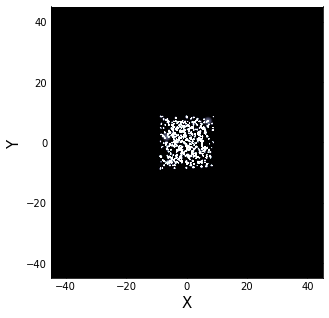

In [ ]:
Particles = sphviewer.Particles(zoom.stars['pos'],zoom.stars['mass'])
Scene = sphviewer.Scene(Particles)
Scene.update_camera(r = 1500, t = 0, extent=[-0.01,0.01,-0.01,0.01])

Render = sphviewer.Render(Scene)
Render.set_logscale()

img = Render.get_image()
extent = Render.get_extent()

In [ ]:
fig = plt.figure(1,figsize=(5,5))
ax1 = fig.add_subplot(111)
ax1.imshow(img, extent=extent, origin='lower', cmap='bone', vmax=0.5)
ax1.set_xlabel('X', size=15)
ax1.set_ylabel('Y', size=15)

In [ ]:
extent

array([-45.00001,  45.00001, -45.00001,  45.00001], dtype=float32)